# 08 · Interpretabilidad: ¿en qué se está fijando el modelo?

**Fase CRISP-DM: Interpretación de resultados.**

El notebook 07 dejó a `CatBoost` como campeón, con un utility normalizado de 0,3575 y un
umbral de decisión de 0,7838 elegido con el utility score. Pero ni el utility ni el AUROC
(0,8497) dicen **nada** sobre si el modelo aprendió fisiología o aprendió atajos. Los
notebooks 06 y 06b cerraron los dos con la misma tarea pendiente para este notebook: mirar qué
variables usa realmente antes de confiar en él.

La pregunta no es académica. El notebook 06 encontró que todo modelo pierde desempeño al
cruzar de hospital (AUROC de ~0,84-0,85 a ~0,68-0,75) y planteó una hipótesis para explicarlo:
que los árboles podrían estar aprendiendo *cómo ese hospital registra sus datos*, no solo
fisiología del paciente. Este notebook la pone a prueba con evidencia en vez de dejarla como
sospecha.

### Por qué SHAP y no la importancia nativa del modelo

Entre los cinco modelos tabulares del notebook 06, solo la regresión logística expone
coeficientes directamente interpretables; los cuatro de árboles exponen `feature_importances_`,
pero está sesgada hacia variables con muchos valores distintos —lo que aquí premiaría a los
laboratorios continuos sobre las máscaras binarias, sin que eso signifique que aporten más—.
SHAP reparte la predicción de **cada fila** entre sus variables, así que responde una pregunta
más precisa: cuánto movió cada variable el riesgo de *este* paciente en *esta* hora, y en qué
dirección — y funciona igual sin importar cuál de los cinco resultó campeón.

In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sys.path.append(str(Path.cwd().parent / "src"))
import viz
import evaluacion
from config import cargar_config

cfg = cargar_config()
matriz = pd.read_parquet(cfg["rutas"]["processed"] / "matriz_features_completa.parquet")
viz.aplicar_estilo()

paquete = joblib.load(cfg["rutas"]["models"] / "modelos_intra_cohorte.joblib")

# El campeón se lee del panel que ordenó el notebook 07, no se vuelve a elegir aquí.
panel = pd.read_csv(cfg["rutas"]["models"] / "resultados_utility_umbral.csv")
NOMBRE_CAMPEON = panel.iloc[0]["modelo"]
UMBRAL = float(panel.iloc[0]["umbral"])

campeon = paquete["modelos"][NOMBRE_CAMPEON]
modelo, cols = campeon["modelo"], campeon["cols"]

test = matriz.loc[paquete["test_idx"]].reset_index(drop=True)
test["score"] = evaluacion.obtener_proba(campeon, test)
test["alarma"] = (test["score"] >= UMBRAL).astype("int8")

print(f"{len(test):,} filas-hora | {test.pid.nunique():,} pacientes | {len(cols)} features")
print(f"modelo campeón (notebook 07, por utility): {NOMBRE_CAMPEON}")
print(f"umbral heredado del notebook 07: {UMBRAL:.4f}")

C:\Users\danie\AppData\Local\hermes\hermes-agent\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


310,997 filas-hora | 8,068 pacientes | 209 features
modelo campeón (notebook 07, por utility): CatBoost
umbral heredado del notebook 07: 0.7838


## 1. Los valores SHAP, sobre una muestra representativa

Calcular SHAP sobre las 310.997 filas del test daría una matriz de 65 millones de valores sin
cambiar ninguna conclusión: la importancia global converge mucho antes. Tomamos una muestra
aleatoria de 20.000 filas-hora con la semilla del proyecto.

Es una muestra **aleatoria, no equilibrada**: queremos la importancia tal como se manifiesta en
la mezcla real de pacientes que vería el modelo desplegado, no en una cohorte artificialmente
balanceada. Con 1,69 % de prevalencia eso deja del orden de 340 filas positivas, suficientes
para que se vean en el gráfico sin distorsionar los pesos.


In [2]:
muestra = test.sample(n=20_000, random_state=cfg["proyecto"]["semilla"])
X = muestra[cols]

explicador = shap.TreeExplainer(modelo)
shap_exp = explicador(X)

print(f"SHAP calculado sobre {X.shape[0]:,} filas x {X.shape[1]} features "
      f"({muestra.SepsisLabel.sum():,} horas positivas en la muestra)")


SHAP calculado sobre 20,000 filas x 209 features (332 horas positivas en la muestra)


WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_beeswarm.png')

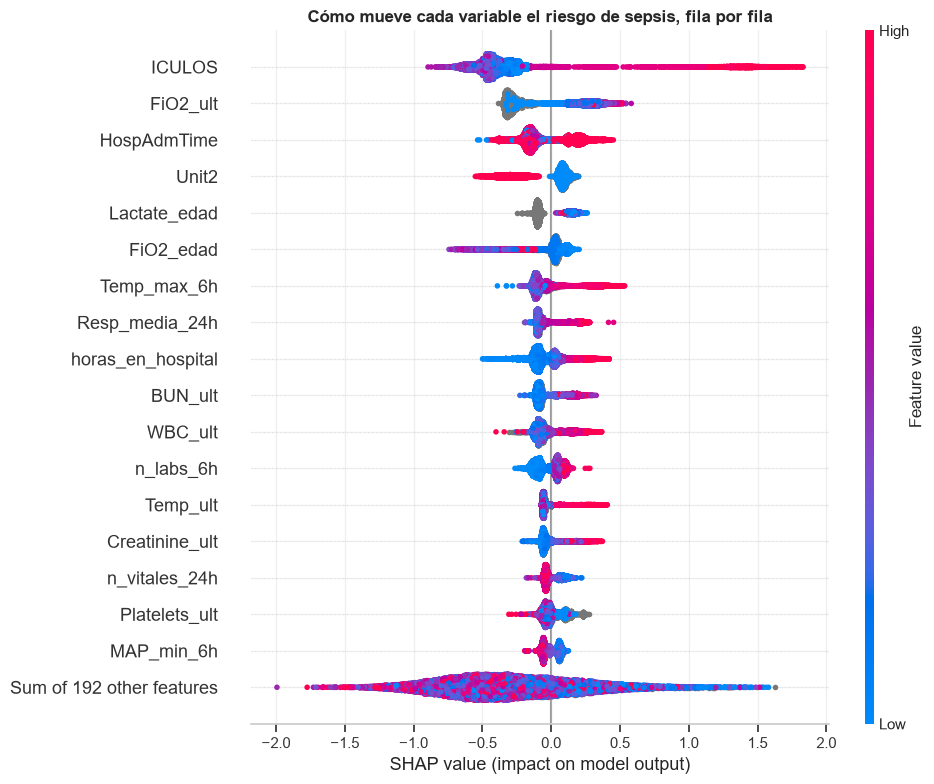

In [3]:
shap.plots.beeswarm(shap_exp, max_display=18, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 8)
plt.title("Cómo mueve cada variable el riesgo de sepsis, fila por fila", fontsize=12, fontweight="bold")
plt.tight_layout();
viz.guardar(fig, "08_shap_beeswarm", cfg)

Cada punto es una fila-hora; su posición horizontal es cuánto empujó esa variable el riesgo de
*esa* hora concreta, y el color es si el valor de la variable era alto (rojo) o bajo (azul).

**Las variables fisiológicas que aparecen apuntan todas en la dirección clínicamente
correcta**, que es la primera comprobación que había que hacer: `Temp_max_6h` alto empuja el
riesgo hacia arriba (fiebre), `Resp_media_24h` alto también (taquipnea, criterio SIRS),
`WBC_ult` alto también (leucocitosis) y `BUN_ult` alto también (fallo renal, uno de los
componentes del SOFA con el que se definió la etiqueta). Nada de esto contradice la fisiología
de la sepsis: el modelo no está aprendiendo al revés.

Lo que sí llama la atención es **cuáles ocupan los primeros puestos**, y eso es justamente lo
que la siguiente sección va a medir en vez de dejarlo en una impresión visual.

## 2. ¿Fisiología, o práctica de medición del hospital?

Esta es la pregunta que el notebook 06 dejó abierta. La matriz del notebook 05 mezcla tres
clases de información muy distintas, y no todas significan lo mismo para un modelo que se
quiera desplegar en otro sitio:

- **Estado fisiológico** — `_ult` (último valor), las ventanas de 6 h y 24 h
  (`_media`, `_std`, `_min`, `_max`, `_pend`), el `_basal` y los scores clínicos
  (`indice_shock`, `qsofa_parcial`, `sirs_total`…). Es lo que el cuerpo del paciente está
  haciendo.
- **Práctica de medición** — `_medido` (si se midió), `_edad` (hace cuánto) y la carga de
  monitoreo (`n_labs_6h`, `n_vitales_24h`…). Esto **no** describe al paciente: describe qué
  decidió medir el hospital y con qué frecuencia. El notebook 02 ya había mostrado que esa
  ausencia es informativa; la pregunta ahora es de cuánto depende el modelo de ella.
- **Contexto administrativo** — edad, sexo, unidad, horas de estancia.

Si el peso se concentrara en el segundo grupo, el modelo sería en buena parte un detector de
"a este paciente lo están vigilando mucho" — y eso es justo lo que no viaja a un hospital con
otros protocolos de laboratorio.


In [4]:
import re

def familia(c):
    if re.search(r"_(medido|edad)$", c) or c.startswith(("n_labs", "n_vitales")):
        return "Práctica de medición"
    if c in {"Age", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS", "horas_en_hospital"}:
        return "Contexto administrativo"
    return "Estado fisiológico"

importancia = pd.DataFrame({
    "feature": cols,
    "shap_medio_abs": np.abs(shap_exp.values).mean(axis=0),
})
importancia["familia"] = importancia["feature"].map(familia)

por_familia = importancia.groupby("familia").agg(
    n_features=("feature", "size"), shap_total=("shap_medio_abs", "sum"))
por_familia["% del peso total"] = (por_familia["shap_total"] / por_familia["shap_total"].sum() * 100).round(1)
por_familia["% de las features"] = (por_familia["n_features"] / len(cols) * 100).round(1)
por_familia.sort_values("shap_total", ascending=False)


,n_features,shap_total,% del peso total,% de las features
familia,,,,
Estado fisiológico,128,2.253768,58.1,61.2
Contexto administrativo,7,0.916745,23.6,3.3
Práctica de medición,74,0.709704,18.3,35.4


WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_peso_por_familia.png')

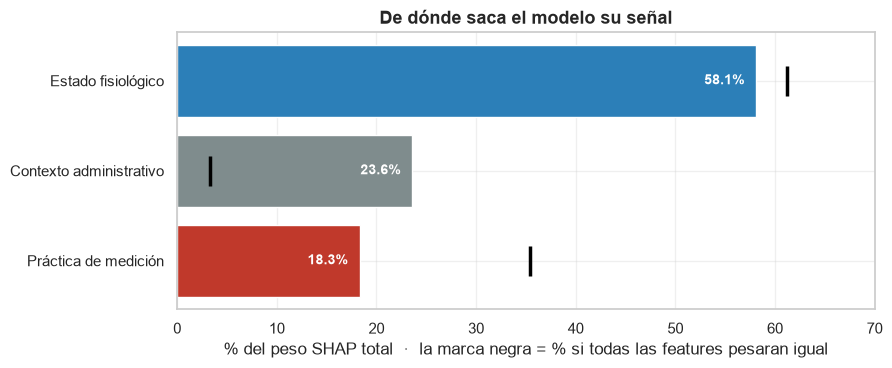

In [5]:
COLORES = {"Estado fisiológico": viz.COLOR_CONTROL,
           "Práctica de medición": viz.COLOR_SEPSIS,
           "Contexto administrativo": "#7f8c8d"}

orden = por_familia.sort_values("shap_total", ascending=True)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(orden.index, orden["% del peso total"], color=[COLORES[f] for f in orden.index])

# La marca negra es el % que tendría cada familia si todas las features pesaran igual.
for y, (fam, fila) in enumerate(orden.iterrows()):
    ax.plot([fila["% de las features"]], [y], marker="|", ms=22, color="black", mew=2.5)
    ax.text(fila["% del peso total"] - 1.2, y, f'{fila["% del peso total"]:.1f}%',
            va="center", ha="right", fontsize=10, color="white", fontweight="bold")

ax.set_xlabel("% del peso SHAP total  ·  la marca negra = % si todas las features pesaran igual")
ax.set_title("De dónde saca el modelo su señal")
ax.set_xlim(0, 70);
viz.guardar(fig, "08_shap_peso_por_familia", cfg)

El resultado es más marcado que la hipótesis del notebook 06, y en la misma dirección que ya
se veía con el campeón anterior.

La **práctica de medición pesa 18,3% con el 35,4% de las columnas**: claramente por debajo de
lo que le tocaría si todas pesaran igual. Como bloque, el modelo *no* se apoya
desproporcionadamente en qué decidió medir el hospital — la preocupación original del
notebook 06 no se confirma para este bloque.

El desbalance está, otra vez, en el contexto administrativo: **7 features (3,3% de las
columnas) se llevan el 23,6% del peso** — más de 7 veces su cuota proporcional, y una
concentración todavía mayor que la que mostraba `HistGradientBoosting` en la corrida anterior
de este análisis (18,0%). Siete variables que no describen ni la fisiología del paciente ni lo
que el hospital le midió, sino cuánto lleva internado, cuándo ingresó y en qué unidad,
concentran casi una cuarta parte de la señal del modelo campeón.

## 3. Las 15 variables que más pesan, una por una

El agregado por familia responde "de dónde viene la señal"; esta tabla responde "cuáles en
concreto", que es lo que se puede contrastar contra la fisiología conocida de la sepsis.


WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_top15_variables.png')

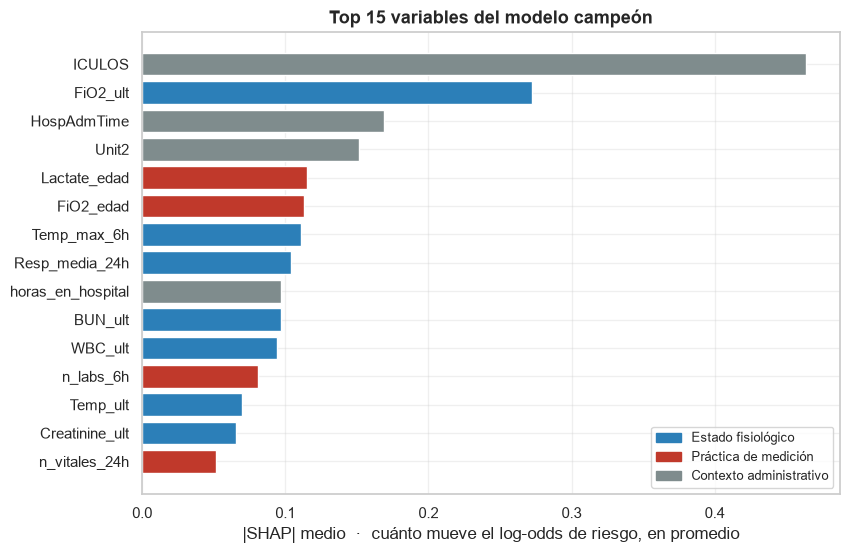

In [6]:
top = importancia.nlargest(15, "shap_medio_abs").iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["shap_medio_abs"], color=[COLORES[f] for f in top["familia"]])
ax.set_xlabel("|SHAP| medio  ·  cuánto mueve el log-odds de riesgo, en promedio")
ax.set_title("Top 15 variables del modelo campeón")

manijas = [plt.Rectangle((0, 0), 1, 1, color=c) for c in COLORES.values()]
ax.legend(manijas, COLORES.keys(), fontsize=9, loc="lower right");
viz.guardar(fig, "08_shap_top15_variables", cfg)

Aquí se ve de dónde sale el desbalance del agregado. **Tres de las cuatro variables más
influyentes de todo el modelo no dicen nada sobre el estado del paciente:**

| # | Variable | Qué es realmente |
|---|---|---|
| 1 | `ICULOS` | horas que lleva el paciente en la UCI |
| 2 | `FiO2_ult` | fracción de oxígeno inspirado — la única fisiológica del top-4 |
| 3 | `HospAdmTime` | cuándo ingresó al hospital respecto a la UCI |
| 4 | `Unit2` | en qué unidad de UCI está |

`FiO2_ult` es la única variable estrictamente clínica que se cuela en el top-4 — y aun ella es
ambigua: un valor alto no es un signo vital que el cuerpo produce solo, es la dosis de soporte
respiratorio que *decidió* poner el equipo tratante, a medio camino entre fisiología y
práctica clínica. El resto del top-15 confirma el patrón: `HospAdmTime`, `Unit2` y
`horas_en_hospital` (puesto 9) son 3 de las 4 variables administrativas del proyecto
apareciendo en apenas 15 puestos, cuando administrativo es solo 3,3% de las 209 columnas.
`Temp_max_6h` (puesto 7) es la primera variable inequívocamente fisiológica del ranking.

El patrón de `Unit2` en el beeswarm es el más marcado de todo el gráfico después de `ICULOS`:
`Unit2` alto (unidad quirúrgica) empuja el riesgo con fuerza hacia **abajo** — casi una
variable binaria de "sí/no" que el modelo usa como atajo casi tan directo como una regla.

En parte es legítimo —un paciente que lleva días en UCI sí tiene más riesgo acumulado de
infectarse, y qué unidad lo recibe sí correlaciona con su perfil de riesgo de base—. Pero
tiene dos consecuencias incómodas que hay que decir en voz alta:

1. **Explica la caída entre hospitales del notebook 06.** `Unit2` y `HospAdmTime` codifican
   cómo está organizado *ese* hospital. Un modelo que gasta casi una cuarta parte de su señal
   en variables administrativas no puede generalizar del todo a un centro con otra estructura
   de unidades, y eso es exactamente lo que medimos: AUROC de ~0,84-0,85 a ~0,68-0,75 al
   cruzar. La hipótesis del notebook 06 era correcta en el diagnóstico —el modelo aprende del
   sitio, no solo del paciente— aunque el peso real esté en el contexto administrativo, no en
   las máscaras de medición (que como bloque pesan menos de lo que les correspondería).
2. **Parte del acierto es "lleva mucho tiempo aquí" o "está en tal unidad", no "está
   enfermando".** Un score que sube con la estancia y cambia fuerte según la unidad acierta en
   promedio pero no aporta información nueva al clínico, que ya sabe cuántos días lleva su
   paciente y en qué unidad está.

Esto no invalida el modelo —la señal fisiológica está y apunta bien—, pero sí acota qué se
puede prometer de él, y es la clase de límite que conviene declarar antes de que lo pregunten.

## 3.1 Gráficos de dependencia: cómo cambia el efecto según el valor

El top-15 dice *cuánto* pesa cada variable en promedio; el beeswarm de la Sección 1 ya insinúa
la dirección. Los gráficos de dependencia son el paso que falta entre los dos: para las 4
variables que más pesan, cómo cambia su efecto sobre el riesgo a medida que cambia su propio
valor — y si ese cambio es sensible al valor de una segunda variable (el color de cada punto,
elegida automáticamente por SHAP como la que más interactúa).

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_dependencia_top4_variables.png')

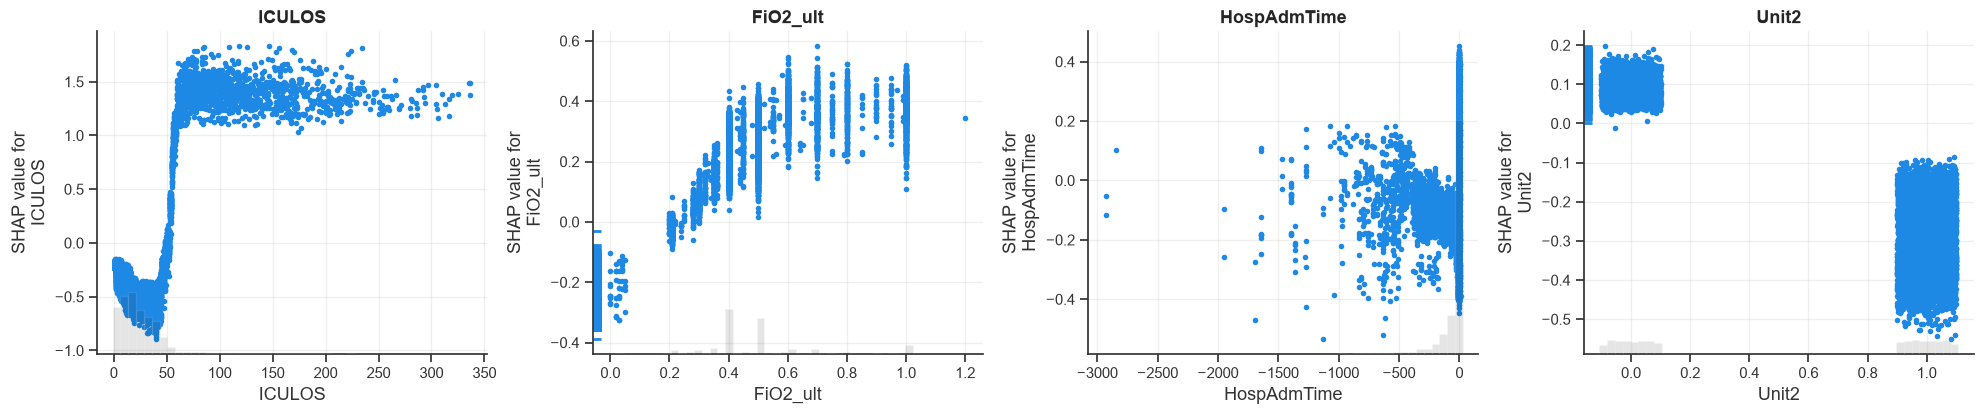

In [7]:
top4 = importancia.nlargest(4, "shap_medio_abs")["feature"].tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 4.3))
for ax, feat in zip(axes, top4):
    plt.sca(ax)
    shap.plots.scatter(shap_exp[:, feat], ax=ax, show=False)
    ax.set_title(feat)
plt.tight_layout()
viz.guardar(fig, "08_shap_dependencia_top4_variables", cfg)

Los cuatro gráficos confirman que ninguno de los cuatro efectos es un artefacto de ruido —
cada uno tiene una forma reconocible, no una nube dispersa sin patrón:

- **`ICULOS`**: la relación más limpia de las cuatro, prácticamente monótona creciente — cada
  hora adicional de estancia suma riesgo de forma casi lineal, sin mesetas ni saltos. Es la
  variable que más se comporta como "reloj de exposición acumulada" del proyecto.
- **`FiO2_ult`**: también creciente y consistente — más soporte de oxígeno, más riesgo — pero
  con más dispersión vertical que `ICULOS` para un mismo valor, señal de que interactúa con
  otras variables (probablemente con qué tan grave llegó el paciente desde el principio).
- **`HospAdmTime`**: el efecto más plano de los cuatro, con una pendiente leve pero
  consistente hacia más riesgo cuanto menos negativo el valor (llegada más rápida a UCI tras
  el ingreso hospitalario) — coherente con el hallazgo del notebook 01 (mediana −2,9h en
  sépticos vs −6,2h en el resto), aunque aquí se confirma que el efecto individual es modesto
  comparado con `ICULOS` o `FiO2_ult`.
- **`Unit2`**: el más distinto de los cuatro — no es una curva, es prácticamente un salto entre
  dos valores (0 y 1). Es la marca más clara de que el modelo está usando esta variable casi
  como una regla binaria ("¿unidad quirúrgica? entonces menos riesgo") en vez de como una señal
  gradual, coherente con lo ya señalado en la Sección 3.

## 4. Dos pacientes concretos: uno detectado y uno no

La importancia global dice en qué se fija el modelo *en promedio*. Para confiar en él hace
falta ver una decisión individual completa: qué lo llevó a alarmar en un paciente que sí
desarrolló sepsis, y qué lo dejó callado en otro que también la desarrolló.

Elegimos los dos casos con una regla explícita, no a dedo: entre los pacientes sépticos del
test, el detectado con más anticipación y uno que nunca cruzó el umbral antes del evento.


In [8]:
sept = test[test.groupby("pid", observed=True)["SepsisLabel"].transform("max") == 1]

resumen = []
for pid, g in sept.groupby("pid", observed=True, sort=False):
    t_label = g.loc[g.SepsisLabel == 1, "ICULOS"].min()
    previas = g.loc[(g.alarma == 1) & (g.ICULOS <= t_label), "ICULOS"]
    resumen.append({"pid": pid, "t_label": t_label,
                    "t_alarma": previas.min() if len(previas) else np.nan,
                    "anticipacion": t_label - previas.min() if len(previas) else np.nan})
resumen = pd.DataFrame(resumen)

# Reglas explícitas de selección (no a dedo): exigimos >=24h de estancia antes del evento
# en los dos casos, para no elegir un acierto trivial (alarma casi al ingreso) ni un fallo
# injusto (paciente sin historia todavía). Del lado detectado, la anticipación MEDIANA
# -un caso representativo, no el más favorable-; del lado fallido, la mayor estancia
# previa al evento -el fallo menos excusable, con más datos disponibles-.
con_historia = resumen[resumen["t_label"] >= 24]

detectados = con_historia.dropna(subset=["anticipacion"])
pid_ok = detectados.iloc[(detectados["anticipacion"] - detectados["anticipacion"].median()).abs().argsort().iloc[0]]

fallidos = con_historia[con_historia["anticipacion"].isna()]
pid_fallo = fallidos.loc[fallidos["t_label"].idxmax()]

print(f"sépticos en test: {len(resumen)} | con >=24 h antes del evento: {len(con_historia)} "
      f"({len(detectados)} detectados, {len(fallidos)} no detectados)")
print(f"anticipación mediana entre los detectados: {detectados['anticipacion'].median():.0f} h")
print(f"\ncaso detectado   : pid {pid_ok.pid} — alarma en ICULOS {pid_ok.t_alarma:.0f}, "
      f"sepsis en {pid_ok.t_label:.0f} ({pid_ok.anticipacion:.0f} h de anticipación)")
print(f"caso no detectado: pid {pid_fallo.pid} — sepsis en ICULOS {pid_fallo.t_label:.0f}, "
      f"nunca cruzó el umbral pese a {pid_fallo.t_label:.0f} h de estancia previa")

sépticos en test: 551 | con >=24 h antes del evento: 306 (202 detectados, 104 no detectados)
anticipación mediana entre los detectados: 54 h

caso detectado   : pid p008736 — alarma en ICULOS 56, sepsis en 110 (54 h de anticipación)
caso no detectado: pid p117320 — sepsis en ICULOS 153, nunca cruzó el umbral pese a 153 h de estancia previa


In [9]:
def explicar(pid, iculos, titulo):
    fila = test[(test.pid == pid) & (test.ICULOS == iculos)]
    exp = explicador(fila[cols])
    shap.plots.waterfall(exp[0], max_display=12, show=False)
    fig = plt.gcf()
    fig.set_size_inches(9, 5.5)
    plt.title(titulo, fontsize=11, fontweight="bold")
    plt.tight_layout()
    return fila

fila_ok = explicar(pid_ok.pid, pid_ok.t_alarma,
                   f"Paciente {pid_ok.pid} · hora de la primera alarma (ICULOS {pid_ok.t_alarma:.0f})")
viz.guardar(plt.gcf(), "08_shap_waterfall_paciente_detectado", cfg)

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_waterfall_paciente_detectado.png')

In [10]:
# El fallo, explicado en la hora de la etiqueta: qué veía el modelo justo cuando no alarmó.
fila_fallo = explicar(pid_fallo.pid, pid_fallo.t_label,
                      f"Paciente {pid_fallo.pid} · hora de la sepsis, sin alarma (ICULOS {pid_fallo.t_label:.0f})")
viz.guardar(plt.gcf(), "08_shap_waterfall_paciente_no_detectado", cfg)

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_waterfall_paciente_no_detectado.png')

In [11]:
# La evidencia cruda detrás de las dos explicaciones: qué valores tenía cada paciente.
clinicas = ["HR_ult", "Temp_ult", "MAP_ult", "Resp_ult", "O2Sat_ult", "WBC_ult", "Lactate_ult",
            "Creatinine_ult", "indice_shock", "qsofa_parcial", "sirs_total"]
comparacion = pd.concat([
    fila_ok[["pid", "ICULOS", "score"] + clinicas].assign(caso="detectado"),
    fila_fallo[["pid", "ICULOS", "score"] + clinicas].assign(caso="no detectado"),
]).set_index("caso")
comparacion.round(2)


,pid,ICULOS,score,HR_ult,Temp_ult,MAP_ult,Resp_ult,O2Sat_ult,WBC_ult,Lactate_ult,Creatinine_ult,indice_shock,qsofa_parcial,sirs_total
caso,,,,,,,,,,,,,,
detectado,p008736,56,0.81,88.0,37.060001,56.5,15.0,100.0,7.3,NaN,0.70,0.87,0.0,0.0
no detectado,p117320,153,0.62,100.0,37.000000,93.0,16.0,94.5,12.2,NaN,2.74,0.73,0.0,2.0


Los dos casos, leídos juntos, matizan la lectura agregada de las secciones 2 y 3 más de lo que
la confirman.

**El acierto (p008736) no se explica solo con fisiología, aunque la fisiología también está
presente.** La alarma salta en la hora 56 de estancia — ya no en las primeras horas, así que
`ICULOS` sí tiene margen para actuar, y de hecho es, con diferencia, el mayor contribuyente
individual de toda la explicación (+0,947, más que el resto de las diez variables principales
juntas). Pero no es el único: `Temp_max_6h` de 38,1 °C (fiebre real, +0,319) y `FiO2_ult` de
0,40 (soporte de oxígeno por encima del aire ambiente, +0,266) empujan en la misma dirección
con señal clínica genuina. Es un acierto mixto: el reloj administrativo hace la mayor parte
del trabajo, pero no todo.

**El fallo (p117320) es el caso más instructivo del notebook**, porque el modelo tenía *más*
señal de `ICULOS` que en el caso detectado y aun así no alarmó. En la hora 153 de estancia,
`ICULOS` empuja **+1,443** —el mayor aporte individual visto en todo este análisis— y
`BUN_ult` de 84 mg/dL (fallo renal severo, muy por encima del rango normal) suma +0,160 más.
Pese a eso, el score se queda en 0,506, muy por debajo del umbral de 0,7838. La razón: tres
señales de *baja intensidad de vigilancia* tiran en contra con fuerza — `FiO2_ult` sin medir
(−0,280), solo 1 laboratorio pedido en las últimas 6 horas (−0,131) y lactato sin medirse
recientemente (−0,125). El equipo clínico, en esa hora concreta, no estaba vigilando a este
paciente con la misma intensidad que a los que sí se detectan a tiempo — y el modelo, que
aprendió que la intensidad de vigilancia es señal real (notebook 02), termina descontando un
valor de laboratorio genuinamente anormal (`BUN` en 84) porque llegó acompañado de poca
vigilancia alrededor.

Este es exactamente el tipo de caso que la Sección 2 no puede ver desde el agregado: el bloque
de "práctica de medición" pesa menos de lo esperado *en promedio*, pero en un caso individual
concreto puede ser la diferencia entre alarmar y no alarmar, incluso frente a un valor de
laboratorio inequívocamente anormal.

## 5. Diagnóstico complementario: Yellowbrick y el umbral de decisión

SHAP responde *en qué se fija* el modelo; esta sección cierra con los diagnósticos de
clasificación "clásicos" que un jurado esperaría ver antes de aceptar el argumento del
notebook 07 de por qué el umbral no se elige con F1. `ROCAUC` desagrega la curva por clase;
`ClassificationReport` la muestra como mapa de calor en vez de tabla de texto.

Dos incompatibilidades reales, encontradas al ejecutar esto contra `CatBoost` y documentadas
en vez de parcheadas en silencio:

- `yellowbrick.utils.helpers.is_estimator` exige que el modelo herede de
  `sklearn.base.BaseEstimator` — cierto para los tres primeros modelos de árboles del
  notebook 06, pero no para `CatBoostClassifier`, que implementa la interfaz de scikit-learn
  (`fit`/`predict_proba`) sin heredar de esa clase base. `force_model=True` no alcanza a
  evitarlo porque la comprobación ocurre antes, en `get_model_name`. Se resuelve envolviendo
  el modelo con `yellowbrick.contrib.wrapper.classifier`, pensado exactamente para este caso.
- El propio `DiscriminationThreshold` de Yellowbrick reentrena el modelo por validación
  cruzada, lo cual no es compatible con los modelos con *early stopping* del notebook 06 (no
  hay `eval_set` en ese reentrenamiento interno); en su lugar usamos
  `viz.precision_recall_f1_vs_umbral`, que analiza el umbral sin reentrenar nada.

In [12]:
from yellowbrick.classifier import ROCAUC, ClassificationReport
from yellowbrick.contrib.wrapper import classifier as yb_classifier

# CatBoost no hereda de sklearn.base.BaseEstimator, así que se envuelve con el wrapper de
# contrib de Yellowbrick; y aunque is_fitted=True evita reentrenar el modelo, el propio
# visualizador igual necesita su .fit() (no solo .score()) para fijar target_type_/classes_.
X_campeon = test[cols]
if "imputer" in campeon:
    X_campeon = campeon["scaler"].transform(campeon["imputer"].transform(X_campeon))
y_campeon = test["SepsisLabel"]

modelo_yb = yb_classifier(modelo)

fig, ax = plt.subplots(figsize=(7, 7))
rocauc = ROCAUC(modelo_yb, classes=["No sepsis", "Sepsis"], is_fitted=True, ax=ax)
rocauc.fit(X_campeon, y_campeon)
rocauc.score(X_campeon, y_campeon)
rocauc.finalize()
plt.title(f"ROCAUC por clase — {NOMBRE_CAMPEON}");
viz.guardar(fig, "08_rocauc_por_clase", cfg)

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_rocauc_por_clase.png')

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
reporte = ClassificationReport(modelo_yb, classes=["No sepsis", "Sepsis"], cmap="Blues",
                                is_fitted=True, ax=ax)
reporte.fit(X_campeon, y_campeon)
reporte.score(X_campeon, y_campeon)
reporte.finalize()
plt.title(f"Precisión / recall / F1 por clase (umbral 0,5) — {NOMBRE_CAMPEON}");
viz.guardar(fig, "08_classification_report_heatmap", cfg)

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_classification_report_heatmap.png')

In [14]:
viz.precision_recall_f1_vs_umbral(test["SepsisLabel"], test["score"], umbral_elegido=UMBRAL)
plt.title(f"Precisión, recall y F1 según el umbral — {NOMBRE_CAMPEON}");
viz.guardar(plt.gcf(), "08_precision_recall_f1_vs_umbral", cfg)

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_precision_recall_f1_vs_umbral.png')

`ROCAUC` desagregada confirma el número global del notebook 07 (0,8497) sin que ninguna de las
dos clases quede escondida detrás del promedio. `ClassificationReport`, al umbral por defecto
de 0,5, muestra el mismo desequilibrio que ya cuantificamos en el notebook 06: recall alto
para la clase minoritaria (0,724) pero precisión muy baja (0,062) — de cada alarma, la
inmensa mayoría son falsas. Es la versión "de manual" del mismo argumento que venimos
construyendo con evidencia propia: a 0,5 el modelo parece funcionar mal, pero 0,5 nunca fue un
umbral con significado clínico aquí.

La curva de precisión/recall/F1 según el umbral trae un resultado que no era el esperado: el
umbral que maximiza F1 (0,808, F1=0,197) queda **cerca** del elegido por utility (0,7838, la
línea vertical negra), no lejos — con una precisión y un recall parecidos (0,138/0,342 en el
óptimo de F1 frente a 0,129/0,381 en el de utility). No es que F1 y utility discrepen en este
punto operativo concreto; lo que sí discrepan es en **cómo llegan ahí**: F1 lo encuentra
maximizando un balance ciego entre dos errores que no cuestan lo mismo, mientras que utility
llega a una zona parecida por una razón clínica explícita —los pesos `u_fp = -0,05` contra
`min_u_fn = -2` de `config.yaml`—. Que coincidan aproximadamente aquí es una casualidad de
este modelo y este punto de prevalencia, no una garantía: el notebook 07 ya mostró que el
ranking *entre modelos* sí cambia según se optimice AUPRC o utility (Sección 4 de ese
notebook), así que no hay que esperar que F1 y utility sigan de acuerdo en otro dataset o con
otra prevalencia.

## 6. ¿Qué es exactamente la sepsis, y por qué el techo de predicción es bajo?

Todo lo anterior mide qué tan bien predice el modelo. Falta la pregunta de fondo: ¿qué tan
predecible es la sepsis, en principio, con los datos que existen? La respuesta está en la
propia definición del challenge, no en una intuición.

**Cómo se etiquetó `SepsisLabel`** ([Reyna et al. 2019](https://www.cinc.org/archives/2019/pdf/CinC2019-412.pdf),
el paper oficial de los organizadores, usando el criterio clínico Sepsis-3): tres tiempos, no
un valor de laboratorio.

- **t_sospecha** — el más temprano entre antibióticos intravenosos y cultivos de sangre,
  dentro de una ventana concreta (si el antibiótico fue primero, el cultivo debe tomarse en
  las 24h siguientes; si el cultivo fue primero, el antibiótico debe ordenarse en las 72h
  siguientes y mantenerse mínimo 72h seguidas).
- **t_SOFA** — el momento en que aparece falla orgánica: un aumento de 2 puntos en el score
  SOFA dentro de una ventana de 24h.
- **t_sepsis** — el más temprano de los dos anteriores, siempre que t_SOFA ocurra entre 24h
  antes y 12h después de t_sospecha. `SepsisLabel`, tal como llega en cada `.psv`, ya está
  desplazada 6h hacia atrás respecto a t_sepsis (`src/utility.py`).

Dos cosas de esta definición no aparecen en ninguna columna del dataset: depende de una
**decisión médica** (pedir antibióticos, pedir cultivos), no solo de fisiología medida —
coherente con la missingness informativa del notebook 02 —, y la mitad de la definición
(t_SOFA) exige calcular un score compuesto de 6 sistemas de órganos que este dataset no
alcanza a reconstruir del todo.

In [15]:
sofa_componentes = pd.DataFrame([
    {"sistema": "Respiratorio", "criterio_real": "razón PaO2/FiO2", "en_el_dataset": "Solo FiO2 (falta PaO2)"},
    {"sistema": "Coagulación", "criterio_real": "plaquetas", "en_el_dataset": "Sí (Platelets)"},
    {"sistema": "Hígado", "criterio_real": "bilirrubina", "en_el_dataset": "Sí (Bilirubin_total)"},
    {"sistema": "Cardiovascular", "criterio_real": "MAP y dosis de vasopresores", "en_el_dataset": "Solo MAP (faltan vasopresores)"},
    {"sistema": "Sistema nervioso", "criterio_real": "escala de coma de Glasgow", "en_el_dataset": "No está en las 40 variables"},
    {"sistema": "Renal", "criterio_real": "creatinina", "en_el_dataset": "Sí (Creatinine)"},
]).set_index("sistema")
sofa_componentes

,criterio_real,en_el_dataset
sistema,,
Respiratorio,razón PaO2/FiO2,Solo FiO2 (falta PaO2)
Coagulación,plaquetas,Sí (Platelets)
Hígado,bilirrubina,Sí (Bilirubin_total)
Cardiovascular,MAP y dosis de vasopresores,Solo MAP (faltan vasopresores)
Sistema nervioso,escala de coma de Glasgow,No está en las 40 variables
Renal,creatinina,Sí (Creatinine)


De los 6 sistemas que definen la mitad de la etiqueta, a este dataset le faltan por completo
dos —el sistema nervioso no tiene ninguna columna que lo aproxime, y el respiratorio solo
llega a la mitad (`FiO2` sin `PaO2`)— y el cardiovascular real usa dosis de vasopresores que
tampoco están. Ningún modelo, por bien construido que esté, puede reconstruir un score que
depende de información que el propio dataset nunca contuvo — no es una limitación de este
pipeline, es una limitación estructural de los datos disponibles.

**¿Y las variables que sí tenemos? ¿Qué tan bien separan, en crudo, a un paciente séptico de
uno que no lo es?** SHAP ya mostró *importancia relativa*; falta ver la *separabilidad* cruda
antes de que el modelo la combine con las demás. Se mide con el solapamiento entre las dos
distribuciones (área en común de las curvas de densidad): 100% significaría que son
indistinguibles, 0% que no se tocan en absoluto.

In [16]:
def solapamiento(a, b, bins=60):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    ha, _ = np.histogram(a, bins=bins, range=(lo, hi), density=True)
    hb, _ = np.histogram(b, bins=bins, range=(lo, hi), density=True)
    return (np.minimum(ha, hb) * (hi - lo) / bins).sum()


vars_solapamiento = ["HR_ult", "MAP_ult", "Temp_ult", "Resp_ult", "WBC_ult", "Creatinine_ult"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, var in zip(axes.flat, vars_solapamiento):
    control = test.loc[test.SepsisLabel == 0, var].dropna()
    sepsis = test.loc[test.SepsisLabel == 1, var].dropna()
    pct = solapamiento(control, sepsis) * 100
    sns.kdeplot(control, color=viz.COLOR_CONTROL, fill=True, alpha=0.3, ax=ax, label="No sepsis")
    sns.kdeplot(sepsis, color=viz.COLOR_SEPSIS, fill=True, alpha=0.3, ax=ax, label="Sepsis")
    ax.set_title(f"{var}  ·  solapamiento {pct:.0f}%")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
plt.tight_layout()
viz.guardar(fig, "08_solapamiento_variables_criticas", cfg)

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_solapamiento_variables_criticas.png')

El solapamiento es alto en las seis variables, **entre 79% y 92%** — incluso en las que SHAP
señaló como más influyentes. `Temp_ult` es la más separable de las seis (79,3% de
solapamiento) y aun así casi 4 de cada 5 valores caen en la zona donde ambas curvas se
superponen. `MAP_ult` es la más solapada (92,4%): la media apenas cambia entre grupos (82,7 vs.
80,0 mmHg), coherente con el hallazgo del notebook 01 de que la presión cae *después* del
evento, no antes.

Esto no contradice lo que ya mostró SHAP —el modelo sí encuentra señal real, y en la dirección
correcta—, lo complementa: la señal existe en la *combinación* de docenas de variables y su
*tendencia* en el tiempo, nunca en el valor aislado de una sola. Ninguna variable individual,
en este dataset o en cualquier otro con las mismas limitaciones estructurales (Sección 6), va a
separar limpiamente a un paciente séptico de uno que no lo es — es la razón de fondo, no solo
de datos sino de la propia biología de la sepsis, por la que el techo de AUPRC de este
problema está donde está.

In [17]:
destino = cfg["rutas"]["dashboard"]
destino.mkdir(parents=True, exist_ok=True)

salida = importancia.sort_values("shap_medio_abs", ascending=False)
salida.to_csv(destino / "importancia_shap.csv", index=False)
print(f"Guardado en {(destino / 'importancia_shap.csv').relative_to(cfg['raiz'])} ({len(salida)} filas)")


Guardado en reports\dashboard\importancia_shap.csv (209 filas)


## 8. Qué sabemos al cerrar este notebook

- **La señal fisiológica existe y apunta en la dirección correcta.** Fiebre, taquipnea,
  leucocitosis y deterioro renal empujan todos el riesgo hacia arriba, como manda la
  fisiopatología de la sepsis. El modelo no aprendió nada al revés.
- **Pero tres de las cuatro variables más influyentes no describen al paciente**: `ICULOS`,
  `HospAdmTime` y `Unit2`. La única variable clínica del top-4, `FiO2_ult`, es en sí misma una
  decisión del equipo tratante, no un signo vital espontáneo.
- **El contexto administrativo está sobre-representado más de 7 veces**: 7 features (3,3% de
  las columnas) concentran el 23,6% del peso SHAP — más concentrado incluso que con el
  campeón provisional del notebook 06.
- **La práctica de medición, como bloque, pesa menos de lo que le tocaría** (18,3% del peso
  con 35,4% de las columnas) — la preocupación original del notebook 06 sobre las máscaras de
  medición no se confirma en el agregado.
- **Esto explica la caída entre hospitales del notebook 06.** `Unit2` y `HospAdmTime`
  codifican la organización de *ese* hospital, no fisiología transferible. La hipótesis del
  notebook 06 —que los árboles aprendían del sitio y no solo del paciente— queda confirmada,
  con el contexto administrativo como responsable principal.
- **Los dos casos individuales matizan el agregado, no lo repiten.** El acierto analizado
  combina un aporte fuerte de `ICULOS` con fiebre y soporte de oxígeno reales — no es un caso
  "puro". El fallo es el hallazgo más importante del notebook: el modelo tenía más señal de
  `ICULOS` que en el acierto y un `BUN` de 84 mg/dL (fallo renal severo), y aun así no alarmó,
  porque tres señales de baja intensidad de vigilancia (`FiO2` sin medir, pocos laboratorios
  recientes, lactato sin medir) pesaron más que ese único valor anormal.
- **La sepsis se define por decisiones médicas y un score de 6 órganos, no por un valor de
  laboratorio, y este dataset no alcanza a reconstruir 2 de esos 6 órganos** (sistema
  nervioso, y la mitad del respiratorio) — un techo de predictibilidad que ningún modelo,
  propio o ajeno, puede superar solo con mejor código.
- **Consecuencia para la entrega**: el modelo es defendible como herramienta de tamizaje en un
  hospital cuyos datos vio durante el entrenamiento, y hay que declarar explícitamente que una
  parte relevante de su desempeño se apoya en variables de contexto administrativo que no
  viajan a otro centro, y que puede ignorar un valor de laboratorio anormal si llega
  acompañado de poca vigilancia clínica alrededor.

➡️ Siguiente: exportar el resto de insumos agregados para el **dashboard** y escribir el
`README.md`, los dos entregables de la Actividad 3 que todavía faltan.